In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

path = "/content/drive/MyDrive/ids_ds"

print(os.listdir(path))

['X_test_clean.csv', 'y_test.csv', 'y_train.csv', 'X_train_clean.csv']


In [3]:
import pandas as pd

path = "/content/drive/MyDrive/ids_ds"

X_train = pd.read_csv(f"{path}/X_train_clean.csv")
X_test = pd.read_csv(f"{path}/X_test_clean.csv")

y_train = pd.read_csv(f"{path}/y_train.csv")
y_test = pd.read_csv(f"{path}/y_test.csv")

In [4]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (148959, 16)
X_test : (29872, 16)
y_train: (148959, 1)
y_test : (29872, 1)


In [5]:
# Convert labels to 1D arrays
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("Training Distribution:")
print(y_train.value_counts())

print("\nTesting Distribution:")
print(y_test.value_counts())

Training Distribution:
Label
1    91611
0    57348
Name: count, dtype: int64

Testing Distribution:
Label
0    17182
1    12690
Name: count, dtype: int64


In [6]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(148959,)


Phase A: Baseline Logistic Regression Model

In this phase, we establish a baseline performance benchmark for binary network intrusion detection using Logistic Regression. The objective is to evaluate how well a simple linear classifier can distinguish between normal and attack traffic before applying more advanced techniques such as cross-validation, hyperparameter tuning, ensemble methods, or deep learning models.

The following tasks will be performed:

Train a Logistic Regression model using the preprocessed training dataset.
Generate predictions on both the training and testing datasets.
Evaluate in-sample (training) performance to understand how well the model fits the training data.
Evaluate out-of-sample (testing) performance to measure the model's generalization capability on unseen data.
Compute key classification metrics, including:
Accuracy
Precision
Recall
F1-Score
ROC-AUC Score
Generate a confusion matrix to analyze correctly and incorrectly classified instances.
Produce a classification report containing class-wise precision, recall, and F1-scores.
Compare training and testing performance to identify potential underfitting or overfitting.
Establish a baseline benchmark that will be used for comparison with tuned Logistic Regression models and other machine learning and deep learning algorithms in later phases.

Expected Outcome:
At the end of this phase, we will have a complete understanding of the baseline performance of Logistic Regression on the intrusion detection dataset and determine whether further optimization is required.

In [ ]:
Phase A: Baseline Logistic Regression

In [7]:
# ============================================================
# Phase A: Baseline Logistic Regression
# ============================================================

# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

# ============================================================
# Train Logistic Regression Model
# ============================================================

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("Training Logistic Regression Model...")
lr_model.fit(X_train, y_train)

print("Model Training Completed!")

Training Logistic Regression Model...
Model Training Completed!


Generate Predictions

In [8]:
# ============================================================
# Predictions on Training Set
# ============================================================

y_train_pred = lr_model.predict(X_train)
y_train_prob = lr_model.predict_proba(X_train)[:, 1]

# ============================================================
# Predictions on Test Set
# ============================================================

y_test_pred = lr_model.predict(X_test)
y_test_prob = lr_model.predict_proba(X_test)[:, 1]

Training Performance (In-Sample)

In [9]:
# ============================================================
# Training Metrics
# ============================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

print("="*50)
print("TRAINING PERFORMANCE")
print("="*50)

print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"F1-Score  : {train_f1:.4f}")
print(f"ROC-AUC   : {train_auc:.4f}")

TRAINING PERFORMANCE
Accuracy  : 0.8970
Precision : 0.9164
Recall    : 0.9162
F1-Score  : 0.9163
ROC-AUC   : 0.9443


In [ ]:
Testing Performance (Out-of-Sample)

In [10]:
# ============================================================
# Testing Metrics
# ============================================================

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\n" + "="*50)
print("TESTING PERFORMANCE")
print("="*50)

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")


TESTING PERFORMANCE
Accuracy  : 0.6483
Precision : 0.6056
Recall    : 0.4938
F1-Score  : 0.5440
ROC-AUC   : 0.6542


In [ ]:
Overfitting / Underfitting Check

In [11]:
# ============================================================
# Generalization Check
# ============================================================

print("\n" + "="*50)
print("GENERALIZATION CHECK")
print("="*50)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

gap = train_accuracy - test_accuracy

print(f"\nAccuracy Gap : {gap:.4f}")

if gap > 0.05:
    print("Potential Overfitting Detected")
else:
    print("Model Generalizes Well")


GENERALIZATION CHECK
Train Accuracy : 0.8970
Test Accuracy  : 0.6483

Accuracy Gap : 0.2487
Potential Overfitting Detected


Confusion Matrix

In [12]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)

print(cm)


CONFUSION MATRIX
[[13101  4081]
 [ 6424  6266]]


Classification Report

In [13]:
# ============================================================
# Classification Report
# ============================================================

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_test, y_test_pred))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.67      0.76      0.71     17182
           1       0.61      0.49      0.54     12690

    accuracy                           0.65     29872
   macro avg       0.64      0.63      0.63     29872
weighted avg       0.64      0.65      0.64     29872



Results Summary Table

In [15]:
# ============================================================
# Results Summary
# ============================================================

results_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Training": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_auc
    ],
    "Testing": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS SUMMARY")
print("="*50)

display(results_lr)


LOGISTIC REGRESSION RESULTS SUMMARY


,Metric,Training,Testing
0,Accuracy,0.897045,0.648333
1,Precision,0.916371,0.605586
2,Recall,0.916211,0.493775
3,F1 Score,0.916291,0.543994
4,ROC-AUC,0.944266,0.654238


## Phase B: 5-Fold Stratified Cross-Validation

In this phase, Stratified K-Fold Cross-Validation is used to evaluate the robustness and stability of the Logistic Regression model. Rather than relying on a single train-test split, the training dataset is divided into five stratified folds while preserving the original class distribution in each fold.

The model is trained and validated five times, using a different fold as the validation set during each iteration. This approach provides a more reliable estimate of model performance and reduces the risk of biased evaluation due to a particular train-test split.

The objectives of this phase are:

1. Evaluate the consistency of Logistic Regression across multiple data partitions.
2. Measure the average performance of the model using cross-validation.
3. Assess the variability of model performance using standard deviation.
4. Detect potential overfitting or instability.
5. Establish a statistically reliable benchmark before hyperparameter tuning.

The following metrics will be evaluated across all folds:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Expected Outcome:
A stable model should exhibit similar performance across all folds with a low standard deviation. Significant variation between folds may indicate model instability or sensitivity to data partitioning.

1. Cross-Validation Evaluation

In [16]:
# ============================================================
# Phase B: 5-Fold Stratified Cross Validation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# Logistic Regression Model
lr_cv = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# 5-Fold Stratified CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to Evaluate
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Perform Cross Validation
cv_results = cross_validate(
    lr_cv,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("Cross Validation Completed!")

Cross Validation Completed!


2. Fold-wise Results

In [17]:
cv_df = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall': cv_results['test_recall'],
    'F1 Score': cv_results['test_f1'],
    'ROC-AUC': cv_results['test_roc_auc']
})

print("Fold-wise Performance")
display(cv_df)

Fold-wise Performance


,Fold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,0.900141,0.918886,0.918736,0.918811,0.945633
1,2,0.896583,0.917768,0.913710,0.915734,0.944546
2,3,0.894838,0.914253,0.914802,0.914527,0.943283
3,4,0.897254,0.915808,0.917258,0.916533,0.944239
4,5,0.896647,0.915907,0.916057,0.915982,0.943531


3. Mean and Standard Deviation

In [18]:
summary_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Mean': [
        np.mean(cv_results['test_accuracy']),
        np.mean(cv_results['test_precision']),
        np.mean(cv_results['test_recall']),
        np.mean(cv_results['test_f1']),
        np.mean(cv_results['test_roc_auc'])
    ],
    'Std Dev': [
        np.std(cv_results['test_accuracy']),
        np.std(cv_results['test_precision']),
        np.std(cv_results['test_recall']),
        np.std(cv_results['test_f1']),
        np.std(cv_results['test_roc_auc'])
    ]
})

print("Cross Validation Summary")
display(summary_df)

Cross Validation Summary


,Metric,Mean,Std Dev
0,Accuracy,0.897092,0.001724
1,Precision,0.916525,0.001623
2,Recall,0.916113,0.001771
3,F1 Score,0.916318,0.001409
4,ROC-AUC,0.944247,0.000831


4. Compact Report

In [19]:
print("="*60)
print("5-FOLD STRATIFIED CROSS VALIDATION RESULTS")
print("="*60)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])

    print(
        f"{metric.upper():<10}: "
        f"{mean_score:.4f} ± {std_score:.4f}"
    )

5-FOLD STRATIFIED CROSS VALIDATION RESULTS
ACCURACY  : 0.8971 ± 0.0017
PRECISION : 0.9165 ± 0.0016
RECALL    : 0.9161 ± 0.0018
F1        : 0.9163 ± 0.0014
ROC_AUC   : 0.9442 ± 0.0008


cross verfications - 1

In [20]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nTrain Statistics")
display(X_train.describe())

print("\nTest Statistics")
display(X_test.describe())

Train Shape: (148959, 16)
Test Shape: (29872, 16)

Train Statistics


,ip_ttl,ip_id,tcp_flag_syn,tcp_flag_ack,tcp_flag_rst,tcp_flag_fin,tcp_flags,tcp_window_size,tcp_ack,tcp_payload_size,flow_relative_time,flow_inter_packet_delay,flow_packet_count,flow_packet_size_stddev,flow_packet_size_skewness,flow_packet_size_kurtosis
count,1.489590e+05,1.489590e+05,148959.000000,148959.000000,148959.000000,148959.000000,148959.000000,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05,1.489590e+05
mean,-9.692753e-17,2.136985e-17,0.010083,0.991212,0.002625,0.006841,0.313791,-3.434440e-18,-1.644715e-16,-9.082186e-17,2.136985e-17,1.469177e-17,9.998037e-17,-1.717220e-16,6.105671e-17,2.442269e-16
std,1.000003e+00,1.000003e+00,0.099908,0.093330,0.051167,0.082426,0.464034,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-7.530948e-01,-1.417858e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-3.540029e-01,-2.240531e+00,-1.133496e+00,-3.824414e-01,-1.516528e-01,-9.205574e-01,-8.716551e-01,-1.846164e+00,-9.151261e-01
25%,-4.741489e-01,-9.202935e-01,0.000000,1.000000,0.000000,0.000000,0.000000,-3.459430e-01,-9.300803e-01,-1.133496e+00,-3.592446e-01,-1.516273e-01,-8.691130e-01,-6.107756e-01,-8.257346e-01,-8.699457e-01
50%,-3.668620e-01,-1.282806e-01,0.000000,1.000000,0.000000,0.000000,0.000000,-3.457128e-01,1.772379e-01,9.084204e-01,-3.104259e-01,-1.515360e-01,-3.758045e-01,-4.238986e-01,1.495995e-01,-4.255659e-01
75%,-1.952031e-01,7.825202e-01,0.000000,1.000000,0.000000,0.000000,1.000000,-2.797371e-01,9.983934e-01,9.084204e-01,-1.509835e-01,-1.505454e-01,6.427160e-01,2.304242e-01,5.877719e-01,7.126780e-01
max,3.710039e+00,1.970501e+00,1.000000,1.000000,1.000000,1.000000,1.000000,7.191745e+00,1.768461e+00,1.061790e+00,1.029186e+01,8.643504e+01,2.736386e+00,3.421118e+00,2.244940e+00,2.687767e+00



Test Statistics


,ip_ttl,ip_id,tcp_flag_syn,tcp_flag_ack,tcp_flag_rst,tcp_flag_fin,tcp_flags,tcp_window_size,tcp_ack,tcp_payload_size,flow_relative_time,flow_inter_packet_delay,flow_packet_count,flow_packet_size_stddev,flow_packet_size_skewness,flow_packet_size_kurtosis
count,29872.000000,29872.000000,29872.00000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000,29872.000000
mean,0.522672,-0.227793,0.01021,0.991129,0.002109,0.002912,0.323380,-0.236569,-0.341201,-0.299681,0.176528,0.018449,-0.808679,0.416609,0.319993,-0.808788
std,1.499092,1.167733,0.10053,0.093770,0.045876,0.053889,0.467774,0.746299,1.045701,0.971330,1.097910,0.587886,0.159696,1.113200,0.355752,0.166500
min,-0.688723,-1.417858,0.00000,0.000000,0.000000,0.000000,0.000000,-0.354003,-2.240531,-1.133496,-0.382441,-0.151653,-0.920557,-0.871655,-0.674278,-0.915126
25%,-0.195203,-1.417858,0.00000,1.000000,0.000000,0.000000,0.000000,-0.340531,-1.279571,-1.133496,-0.373325,-0.151630,-0.904606,-0.530185,0.101442,-0.899254
50%,-0.195203,-0.451011,0.00000,1.000000,0.000000,0.000000,0.000000,-0.324987,-0.245894,-1.086883,-0.354535,-0.151528,-0.871506,0.099054,0.378937,-0.872100
75%,-0.195203,0.875172,0.00000,1.000000,0.000000,0.000000,1.000000,-0.296317,0.408002,0.878348,0.179593,-0.149237,-0.782973,1.182754,0.513925,-0.802798
max,3.688582,1.966882,1.00000,1.000000,1.000000,1.000000,1.000000,7.191745,1.754742,1.061790,4.751840,17.271144,-0.012104,3.491666,1.558655,0.296173


In [21]:
comparison = pd.DataFrame({
    'Train Mean': X_train.mean(),
    'Test Mean': X_test.mean(),
    'Train Std': X_train.std(),
    'Test Std': X_test.std()
})

display(comparison)

,Train Mean,Test Mean,Train Std,Test Std
ip_ttl,-9.692753e-17,0.522672,1.000003,1.499092
ip_id,2.136985e-17,-0.227793,1.000003,1.167733
tcp_flag_syn,1.008331e-02,0.010210,0.099908,0.100530
tcp_flag_ack,9.912123e-01,0.991129,0.093330,0.093770
tcp_flag_rst,2.624883e-03,0.002109,0.051167,0.045876
tcp_flag_fin,6.840809e-03,0.002912,0.082426,0.053889
tcp_flags,3.137910e-01,0.323380,0.464034,0.467774
tcp_window_size,-3.434440e-18,-0.236569,1.000003,0.746299
tcp_ack,-1.644715e-16,-0.341201,1.000003,1.045701
tcp_payload_size,-9.082186e-17,-0.299681,1.000003,0.971330


## Phase C: Hyperparameter Tuning using GridSearchCV

In this phase, hyperparameter optimization is performed to improve the performance of the Logistic Regression model. The baseline model uses default parameter values, which may not be optimal for the intrusion detection dataset.

A grid search strategy is employed to systematically explore different combinations of hyperparameters and identify the configuration that produces the best cross-validation performance.

The following hyperparameters are investigated:

- Regularization Strength (C)
- Regularization Type (L1 and L2)
- Class Weighting Strategy
- Optimization Solver

A 5-fold Stratified Cross-Validation approach is used during the search process to ensure reliable and unbiased model evaluation.

Objectives:

1. Identify the optimal Logistic Regression configuration.
2. Improve classification performance.
3. Reduce model bias and variance.
4. Enhance generalization capability.
5. Compare tuned performance against the baseline model.

Expected Outcome:

The best-performing hyperparameter combination will be selected and used to train a final optimized Logistic Regression model for further evaluation on the unseen test dataset.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Base Model
lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

print("Starting Grid Search...")

grid_search.fit(X_train, y_train)

print("\nGrid Search Completed!")

Starting Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid Search Completed!


In [23]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 100, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.9165075096191957


In [24]:
best_lr = grid_search.best_estimator_

print(best_lr)

LogisticRegression(C=100, max_iter=3000, random_state=42, solver='liblinear')


In [25]:
grid_search.best_params_
grid_search.best_score_

np.float64(0.9165075096191957)

## Phase D.1: In-Sample and Out-of-Sample Evaluation of the Tuned Logistic Regression Model

After identifying the optimal hyperparameters, the tuned Logistic Regression model is evaluated on both the training dataset (in-sample evaluation) and the testing dataset (out-of-sample evaluation).

The purpose of this analysis is to:

1. Measure the model's fit on the training data.
2. Measure the model's generalization performance on unseen data.
3. Detect potential overfitting or underfitting.
4. Compare the tuned model's behavior with the baseline Logistic Regression model.

The following metrics are evaluated for both datasets:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

A comparison between training and testing performance is used to assess the model's ability to generalize.

In [27]:
# ============================================================
# Tuned Model: In-Sample vs Out-of-Sample Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Training Predictions
y_train_pred = best_lr.predict(X_train)
y_train_prob = best_lr.predict_proba(X_train)[:, 1]

# Testing Predictions
y_test_pred = best_lr.predict(X_test)
y_test_prob = best_lr.predict_proba(X_test)[:, 1]

# -------------------------
# Training Metrics
# -------------------------

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# -------------------------
# Testing Metrics
# -------------------------

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# -------------------------
# Results Table
# -------------------------

results_tuned_lr = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Training': [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1,
        train_auc
    ],
    'Testing': [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc
    ]
})

display(results_tuned_lr)

,Metric,Training,Testing
0,Accuracy,0.897213,0.648634
1,Precision,0.916112,0.606154
2,Recall,0.916822,0.493617
3,F1 Score,0.916467,0.544128
4,ROC-AUC,0.944249,0.654381


In [28]:
print("="*60)
print("GENERALIZATION ANALYSIS")
print("="*60)

print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

gap = train_accuracy - test_accuracy

print(f"\nAccuracy Gap : {gap:.4f}")

if gap > 0.05:
    print("Potential Overfitting / Distribution Shift")
else:
    print("Good Generalization")

GENERALIZATION ANALYSIS
Train Accuracy : 0.8972
Test Accuracy  : 0.6486

Accuracy Gap : 0.2486
Potential Overfitting / Distribution Shift


## Phase E: Diagnostic Evaluation of the Optimized Logistic Regression Model

In this phase, graphical diagnostic techniques are used to further analyze the performance of the optimized Logistic Regression model.

While numerical metrics such as accuracy, precision, recall, and F1-score provide a summary of model performance, graphical evaluation offers deeper insight into the classifier's behavior across different decision thresholds.

The following diagnostic analyses are performed:

1. Receiver Operating Characteristic (ROC) Curve
2. Area Under the ROC Curve (ROC-AUC)
3. Precision-Recall Curve
4. Confusion Matrix Visualization

These analyses help assess the model's discrimination capability, classification behavior, and suitability for network intrusion detection applications.

Expected Outcome:

A well-performing classifier should exhibit:
- A ROC curve close to the upper-left corner.
- A high ROC-AUC score.
- Strong precision-recall trade-offs.
- A confusion matrix with a low number of false negatives and false positives.

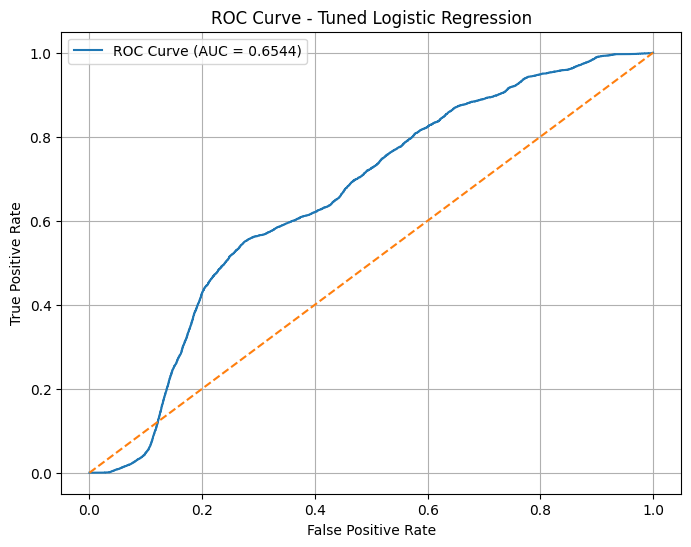

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob = best_lr.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,
         label=f'ROC Curve (AUC = {auc_score:.4f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.grid(True)

plt.show()

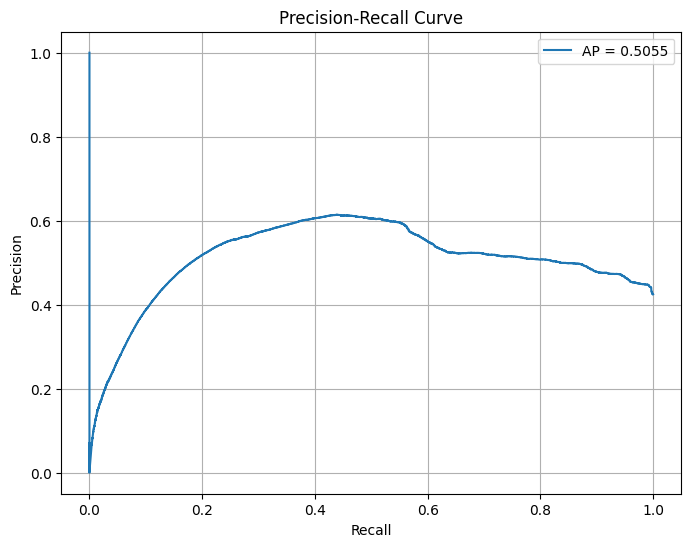

In [30]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(
    recall,
    precision,
    label=f'AP = {ap_score:.4f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

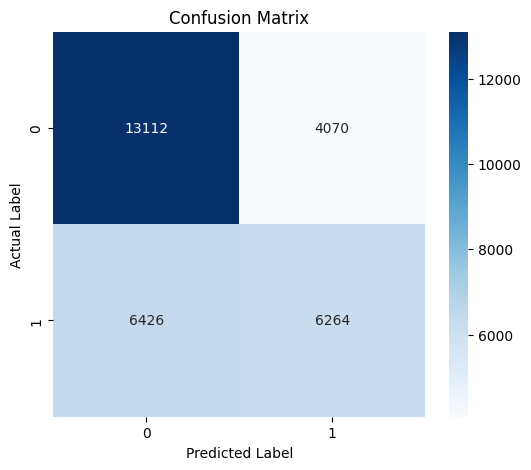

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

## Threshold Analysis

Logistic Regression produces probability estimates for each observation. By default, a probability threshold of 0.5 is used to assign class labels.

In intrusion detection systems, the choice of threshold significantly affects the trade-off between precision and recall. Lower thresholds generally increase attack detection rates (recall) but may also increase false alarms (false positives).

To study this trade-off, the tuned Logistic Regression model is evaluated using multiple probability thresholds. The resulting precision, recall, F1-score, and accuracy values are compared to identify the threshold that provides the most suitable balance for intrusion detection.

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

# Probabilities from tuned model
y_prob = best_lr.predict_proba(X_test)[:, 1]

for threshold in thresholds:

    y_pred_thresh = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1 Score": f1_score(y_test, y_pred_thresh)
    })

threshold_df = pd.DataFrame(results)

print("Threshold Analysis Results")
display(threshold_df)

Threshold Analysis Results


,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.600194,0.524092,0.640268,0.576384
1,0.4,0.630892,0.563069,0.585343,0.573990
2,0.5,0.648634,0.606154,0.493617,0.544128
3,0.6,0.609501,0.575158,0.309062,0.402071
4,0.7,0.548674,0.374365,0.092987,0.148971


Threshold analysis revealed that the default classification threshold of 0.5 was not optimal for the intrusion detection task. A threshold of 0.3 produced the highest F1-score (57.64%) and significantly improved attack detection recall from 49.36% to 64.03%. Since intrusion detection systems prioritize identifying malicious traffic, a lower threshold may be preferred despite the increase in false positives.

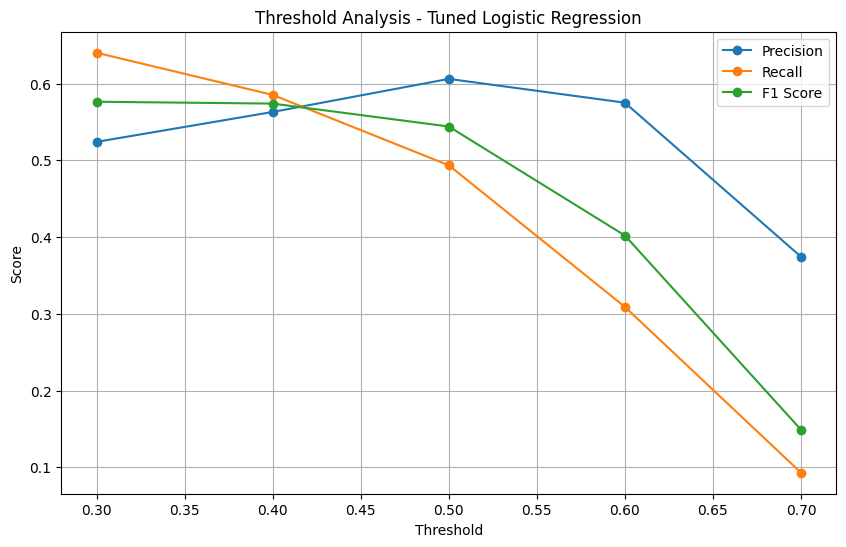

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Tuned Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

## Phase F: Feature Importance Analysis

To understand which network traffic characteristics contribute most to intrusion detection, feature importance analysis is performed using the coefficients of the optimized Logistic Regression model.

In Logistic Regression, the magnitude of a coefficient reflects the strength of its influence on the predicted outcome. Positive coefficients increase the likelihood of an attack prediction, while negative coefficients decrease it.

Feature importance analysis improves model interpretability and helps identify the most influential network traffic attributes used during classification.

In [34]:
import pandas as pd
import numpy as np

# Extract coefficients
coefficients = best_lr.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.reset_index(
    drop=True,
    inplace=True
)

display(feature_importance)

,Feature,Coefficient,Abs_Coefficient
0,tcp_flag_syn,-17.088868,17.088868
1,tcp_flag_fin,-5.219574,5.219574
2,flow_packet_size_kurtosis,5.121410,5.121410
3,flow_packet_count,-3.842496,3.842496
4,tcp_flag_ack,2.259663,2.259663
5,flow_packet_size_skewness,-2.109413,2.109413
6,tcp_window_size,1.772585,1.772585
7,flow_packet_size_stddev,-0.979047,0.979047
8,tcp_flag_rst,-0.868119,0.868119
9,ip_ttl,-0.649287,0.649287


Positive coefficient → pushes prediction toward Attack (1)
Negative coefficient → pushes prediction toward Normal (0)
Large absolute value → strong influence
Small absolute value → weak influence

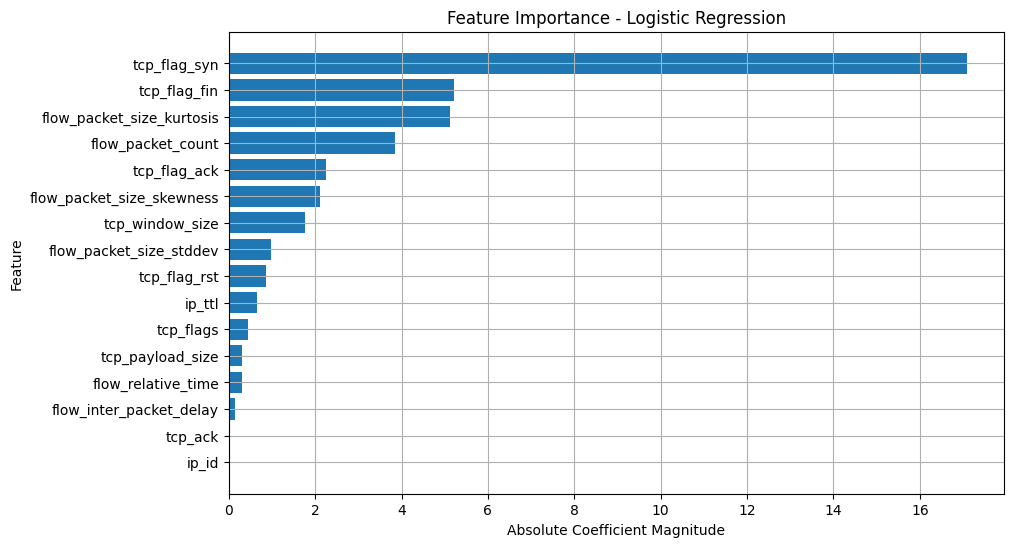

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Abs_Coefficient']
)

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Feature Importance - Logistic Regression")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [37]:
comparison_lr = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Baseline LR': [
        0.648333,
        0.605586,
        0.493775,
        0.543994,
        0.654238
    ],
    'Tuned LR': [
        0.648634,
        0.606154,
        0.493617,
        0.544128,
        0.654381
    ]
})

comparison_lr['Difference'] = (
    comparison_lr['Tuned LR']
    - comparison_lr['Baseline LR']
)

display(comparison_lr)

,Metric,Baseline LR,Tuned LR,Difference
0,Accuracy,0.648333,0.648634,0.000301
1,Precision,0.605586,0.606154,0.000568
2,Recall,0.493775,0.493617,-0.000158
3,F1 Score,0.543994,0.544128,0.000134
4,ROC-AUC,0.654238,0.654381,0.000143
